# Optimized Related-Run Artifact Workflow

This notebook is the notebook version of the newer end-to-end related-run workflow test.

It shows how to:

- build a modest optimized `TriangleGrid -> VoronoiGridPlus` mesh
- create a source model run directly with `SimulationBase`
- capture reusable artifacts while defining packages
- derive modified artifacts for a related scenario
- build a related run on the same optimized grid
- validate and auto-apply artifacts
- compare heads between the source and related runs


In [1]:
from pathlib import Path
import shutil
import sys

import geopandas as gpd
import numpy as np
from shapely.geometry import LineString, Point, Polygon


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for path in [start, *start.parents]:
        if (path / "src" / "simple_modflow").exists():
            return path
    raise RuntimeError("Could not find the simple_modflow repo root from the current notebook location.")


ROOT = find_repo_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import simple_modflow as mf
from simple_modflow.modflow.mf6.grid.triangle import TriangleGrid, MeshBuildProfile
from simple_modflow.modflow.mf6.lakes import LakeConnectionData, LakePackageData, LakePeriodData
from simple_modflow.modflow.mf6.sfr import SFR
from simple_modflow.modflow.mf6.simulation.discretization import DisvGrid, TemporalDiscretization
from simple_modflow.modflow.mf6.simulation.packages import CHD, InitialConditions, KFlow, LAK, OutputControl, Recharge, Storage
from simple_modflow.modflow.mf6.uzf import UZFPackageData


workspace = ROOT / "examples" / "mf6" / "artifacts" / "optimized_related_run_artifact_workflow"
if workspace.exists():
    shutil.rmtree(workspace)
workspace.mkdir(parents=True, exist_ok=True)

workspace

WindowsPath('c:/Users/lukem/Python/Projects/simple_modflow/examples/mf6/artifacts/optimized_related_run_artifact_workflow')

In [5]:
def write_gpkg(path: Path, gdf: gpd.GeoDataFrame) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists():
        path.unlink()
    gdf.to_file(path, driver="GPKG")
    return path


def build_small_optimized_vor(workspace: Path):
    domain_geom = Polygon([(0.0, 0.0), (520.0, 0.0), (520.0, 420.0), (0.0, 420.0)])
    lake_geom = Point(180.0, 160.0).buffer(52.0)
    stream_line = LineString([(35.0, 355.0), (210.0, 265.0), (485.0, 120.0)])

    tri = TriangleGrid(model_ws=str(workspace / "triangle_build"))
    tri.set_domain_polygon(domain_geom)
    tri.add_region_polygon(
        Polygon([(45.0, 45.0), (475.0, 45.0), (475.0, 375.0), (45.0, 375.0)]),
        max_area=18000,
        label="mid_refine",
    )
    tri.add_region_polygon(
        stream_line.buffer(28.0),
        max_area=3500,
        label="stream_refine",
        priority=2,
        source="line",
    )
    tri.add_region_polygon(
        lake_geom,
        max_area=900,
        label="lake_refine",
        priority=3,
        source="circle",
    )
    mesh_report = tri.build_mesh(profile='clean', verbose=True)

    vor = mf.VoronoiGridPlus(tri)
    top = 118.0 - (0.02 * np.asarray(vor.centroids_x)) + (0.009 * np.asarray(vor.centroids_y))
    bottom = top - 34.0
    vor.gdf_topbtm = gpd.GeoDataFrame(
        {
            "geometry": vor.gdf_vorPolys.geometry,
            0: top,
            1: bottom,
        },
        geometry="geometry",
        crs=vor.crs,
    )
    geometries = {
        "domain": domain_geom,
        "lake": lake_geom,
        "stream": stream_line,
        "east_boundary": Polygon([(470.0, 0.0), (520.0, 0.0), (520.0, 420.0), (470.0, 420.0)]),
    }
    return vor, mesh_report, geometries


vor, mesh_report, geometries = build_small_optimized_vor(workspace)
mesh_report

Opening _triangle.0.poly.
Opening _triangle.0.node.
Constructing Delaunay triangulation by divide-and-conquer method.
  Sorting vertices.
  Forming triangulation.
  Removing ghost triangles.
Recovering segments in Delaunay triangulation.
    Constructing mapping from vertices to triangles.
  Recovering PSLG segments.
Removing unwanted triangles.
  Marking concavities (external triangles) for elimination.
Spreading regional attributes and area constraints.
Adding Steiner points to enforce quality.
  Looking for encroached subsegments.
  Splitting encroached subsegments.
  Making a list of bad triangles.
  Splitting bad triangles.

Writing _triangle.1.node.
Writing _triangle.1.ele.
Writing _triangle.1.poly.
Writing _triangle.1.edge.
Writing _triangle.1.neigh.

Statistics:

  Input vertices: 34
  Input segments: 34
  Input holes: 0

  Mesh vertices: 1552
  Mesh triangles: 3036
  Mesh edges: 4587
  Mesh exterior boundary edges: 66
  Mesh interior boundary edges: 414
  Mesh subsegments (con

{'cleanup': {'snap_tolerance': 0.0,
  'simplify_tolerance': 2.0,
  'min_feature_area': 0.0,
  'target_segment_length': 120.0,
  'resample_domain_boundary': False,
  'resample_region_sources': 'line',
  'vertices_before': 145,
  'vertices_after': 38,
  'polygons_before': 4,
  'polygons_after': 4},
 'optimization': None,
 'quality': {'num_triangles': 3036,
  'num_vertices': 1552,
  'num_boundary_vertices': 476,
  'num_interior_vertices': 1076,
  'duplicate_vertex_count': 0,
  'zero_area_triangle_count': 0,
  'tiny_triangle_count': 0,
  'sliver_triangle_count': 20,
  'triangle_area_min': 0.004002662051786713,
  'triangle_area_mean': 71.93675889328063,
  'triangle_area_max': 1462.5,
  'triangle_area_std': 179.8275728681111,
  'edge_length_min': 0.04402730580894713,
  'edge_length_mean': 7.130733476201151,
  'edge_length_max': 70.18540328051262,
  'edge_length_std': 11.475452870997277,
  'triangle_angle_min': 0.6306478850373597,
  'triangle_angle_mean': 60.0,
  'triangle_angle_max': 115.226

In [6]:
catalog = mf.ProjectCatalog(workspace / "catalog", name="optimized_related_run_demo")
catalog.register_model_spec(
    mf.ModelSpec(name="small_feature_model", grid_ref="optimized_small_voronoi"),
    overwrite=True,
)

top = vor.gdf_topbtm[0].tolist()
bottom = vor.gdf_topbtm[1].tolist()
centroids_x = np.asarray(vor.centroids_x, dtype=float)
left_cells = [cell for cell, x in enumerate(centroids_x) if x < 260.0]
east_cells = sorted(set(vor.get_vor_cells_as_series(geometries["east_boundary"]).iloc[0]))

lake_path = write_gpkg(
    workspace / "lake.gpkg",
    gpd.GeoDataFrame({"name": ["lake_0"]}, geometry=[geometries["lake"]], crs=vor.crs),
)
stream_path = write_gpkg(
    workspace / "stream.gpkg",
    gpd.GeoDataFrame({"name": ["stream_0"]}, geometry=[geometries["stream"]], crs=vor.crs),
)

baseline_east_head = 98.75
baseline_rch_rows = []
baseline_finf = []
for cell in range(vor.ncpl):
    if cell in left_cells:
        baseline_rch_rows.append([(0, cell), 0.0018])
        baseline_finf.append(0.00045)
    else:
        baseline_rch_rows.append([(0, cell), 0.0011])
        baseline_finf.append(0.00025)

source_model = mf.SimulationBase(
    vor=vor,
    nper=1,
    project_catalog=catalog,
    run_id="source_run",
    model_spec="small_feature_model",
)
DisvGrid(vor=vor, model=source_model, top=top, bottom=[bottom], nlay=1)
TemporalDiscretization(model=source_model, per_len=1, num_steps=1, multiplier=1.0)
InitialConditions(model=source_model, vor=vor, nlay=1, strt=(np.asarray(top) - 4.0).tolist(), artifact_id="baseline_ic")
KFlow(model=source_model, k=[12.0] * vor.ncpl, save_specific_discharge=False, artifact_id="baseline_npf")
Storage(model=source_model, sto_steady={0: True}, sto_transient={})
OutputControl(model=source_model)
CHD(
    model=source_model,
    stress_period_data={0: [[(0, cell), baseline_east_head] for cell in east_cells]},
    artifact_id="baseline_chd",
)
Recharge(model=source_model, rch_dict={0: baseline_rch_rows}, artifact_id="baseline_rch")
UZFPackageData(
    model=source_model,
    vor=vor,
    uzf_cells=[(0, cell) for cell in range(vor.ncpl)],
    vks=0.45,
    thtr=0.1,
    thts=0.3,
    thti=0.2,
    finf={0: baseline_finf},
    add_uzf=True,
    artifact_id="baseline_uzf",
)

lake_connections = LakeConnectionData(
    model=source_model,
    vor=vor,
    paths=[lake_path],
    bed_leakance=0.05,
    horizontal_connections={0: [100.0, 95.0]},
    use_reconciled_surfaces=False,
    only_vertical=True,
)
lake_packagedata = LakePackageData(
    nlakes=1,
    starting_stage=[100.0],
    connectiondata=lake_connections.connection_data,
)
lake_perioddata = LakePeriodData(model=source_model, lake_ids=[0], lake_stages=[100.0], status=["ACTIVE"])
LAK(
    model=source_model,
    nlakes=1,
    noutlets=0,
    ntables=0,
    packagedata=lake_packagedata.packagedata,
    connectiondata=lake_connections.connection_data,
    perioddata=lake_perioddata.perioddata,
    mover=False,
    artifact_id="baseline_lak",
)
SFR(
    model=source_model,
    vor=vor,
    stream_paths=[stream_path],
    inflows={0: [(0, 0.2)]},
    widths=10.0,
    gradients=0.001,
    mannings=0.03,
    streambed_k=1.0,
    streambed_thickness=1.0,
    mover=False,
    add_sfr=True,
    artifact_id="baseline_sfr",
)

success, _ = source_model.run_simulation()
print("source run success:", success)
catalog.list_package_artifacts()

1552
Imported 1 features from c:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts\optimized_related_run_artifact_workflow\lake.gpkg
Generating connections (rectangular mode) for lake 0
getting connectivity properties (iac, ja, cl12, hwva, nja)
Getting package data for 1 lakes
initing sfr
Stream 0: applying 10.0 for rwid to all reaches
Stream 0: applying 0.001 for rgrd to all reaches
Stream 0: applying 0.03 for man to all reaches
Stream 0: applying 1.0 for rhk to all reaches
Stream 0: applying 1.0 for rbth to all reaches
Adding SFR package
writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_gwf...
  writing model source_run...
    writing model name file...
    writing package disv...
    writing package ic...
    writing package npf...
    writing package sto...
    writing package oc...
    writing package chd...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 135 based on size o

,artifact_id,package_type,source_run_id,source_workspace,source_package_name,storage_mode,derived_from_artifact_id,derived_from_run_id,tags
0,baseline_chd,chd,source_run,c:\Users\lukem\Python\Projects\simple_modflow\...,CHD,snapshot,None,None,[]
1,baseline_ic,ic,source_run,c:\Users\lukem\Python\Projects\simple_modflow\...,IC,snapshot,None,None,[]
2,baseline_lak,lak,source_run,c:\Users\lukem\Python\Projects\simple_modflow\...,LAK,snapshot,None,None,[]
3,baseline_npf,npf,source_run,c:\Users\lukem\Python\Projects\simple_modflow\...,NPF,snapshot,None,None,[]
4,baseline_rch,rch,source_run,c:\Users\lukem\Python\Projects\simple_modflow\...,RCH,snapshot,None,None,[]
5,baseline_sfr,sfr,source_run,c:\Users\lukem\Python\Projects\simple_modflow\...,SFR,snapshot,None,None,[]
6,baseline_uzf,uzf,source_run,c:\Users\lukem\Python\Projects\simple_modflow\...,UZF,snapshot,None,None,[]


In [7]:
catalog.derive_package_artifact(
    "baseline_chd",
    artifact_id="variant_chd",
    description="Lower east boundary stages",
    package_data_updates={
        "stress_period_data": {
            "0": [[[0, int(cell)], baseline_east_head - 1.0] for cell in east_cells],
        }
    },
    overwrite=True,
)
catalog.derive_package_artifact(
    "baseline_rch",
    artifact_id="variant_rch",
    description="Reduced recharge for related scenario",
    package_data_updates={
        "stress_period_data": {
            "0": [
                [[0, int(cell)], 0.00135 if cell in left_cells else 0.0007]
                for cell in range(vor.ncpl)
            ],
        }
    },
    overwrite=True,
)

catalog.list_package_artifacts()

,artifact_id,package_type,source_run_id,source_workspace,source_package_name,storage_mode,derived_from_artifact_id,derived_from_run_id,tags
0,baseline_chd,chd,source_run,c:\Users\lukem\Python\Projects\simple_modflow\...,CHD,snapshot,None,None,[]
1,baseline_ic,ic,source_run,c:\Users\lukem\Python\Projects\simple_modflow\...,IC,snapshot,None,None,[]
2,baseline_lak,lak,source_run,c:\Users\lukem\Python\Projects\simple_modflow\...,LAK,snapshot,None,None,[]
3,baseline_npf,npf,source_run,c:\Users\lukem\Python\Projects\simple_modflow\...,NPF,snapshot,None,None,[]
4,baseline_rch,rch,source_run,c:\Users\lukem\Python\Projects\simple_modflow\...,RCH,snapshot,None,None,[]
5,baseline_sfr,sfr,source_run,c:\Users\lukem\Python\Projects\simple_modflow\...,SFR,snapshot,None,None,[]
6,baseline_uzf,uzf,source_run,c:\Users\lukem\Python\Projects\simple_modflow\...,UZF,snapshot,None,None,[]
7,variant_chd,chd,source_run,c:\Users\lukem\Python\Projects\simple_modflow\...,CHD,snapshot,baseline_chd,source_run,[]
8,variant_rch,rch,source_run,c:\Users\lukem\Python\Projects\simple_modflow\...,RCH,snapshot,baseline_rch,source_run,[]


In [8]:
related_model = mf.SimulationBase(
    vor=vor,
    nper=1,
    project_catalog=catalog,
    run_id="related_run",
    model_spec="small_feature_model",
    package_versions={
        "ic": "baseline_ic",
        "npf": "baseline_npf",
        "chd": "variant_chd",
        "rch": "variant_rch",
        "uzf": "baseline_uzf",
        "lak": "baseline_lak",
        "sfr": "baseline_sfr",
    },
)
DisvGrid(vor=vor, model=related_model, top=top, bottom=[bottom], nlay=1)
TemporalDiscretization(model=related_model, per_len=1, num_steps=1, multiplier=1.0)
Storage(model=related_model, sto_steady={0: True}, sto_transient={})
OutputControl(model=related_model)

validation = related_model.validate_referenced_package_artifacts()
validation

,artifact_id,package_type,valid,dependencies,missing_dependencies,issue_count,message,package_key
0,baseline_ic,ic,True,[],[],0,ok,ic
1,baseline_npf,npf,True,[],[],0,ok,npf
2,variant_chd,chd,True,[],[],0,ok,chd
3,variant_rch,rch,True,[],[],0,ok,rch
4,baseline_uzf,uzf,True,[],[],0,ok,uzf
5,baseline_lak,lak,True,[],[],0,ok,lak
6,baseline_sfr,sfr,True,[],[],0,ok,sfr


In [9]:
source_heads = source_model.hds.get_data(kstpkper=(0, 0)).squeeze()
success, _ = related_model.run_simulation()
related_heads = related_model.hds.get_data(kstpkper=(0, 0)).squeeze()

print("related run success:", success)
print("attached artifacts:", related_model.attached_package_artifacts)
print("mean source head:", float(np.mean(source_heads)))
print("mean related head:", float(np.mean(related_heads)))
print("mean head difference:", float(np.mean(related_heads - source_heads)))

comparison = gpd.GeoDataFrame(
    {
        "source_head": source_heads,
        "related_head": related_heads,
        "head_diff": related_heads - source_heads,
    },
    geometry=vor.gdf_vorPolys.geometry,
    crs=vor.crs,
)
comparison.head()

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_gwf...
  writing model related_run...
    writing model name file...
    writing package disv...
    writing package sto...
    writing package oc...
    writing package ic...
    writing package npf...
    writing package rch...
    writing package chd...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 135 based on size of stress_period_data
    writing package uzf...
    writing package lak...
    writing package sfr...

Saved model object to .model file: c:\Users\lukem\Python\Projects\simple_modflow\examples\mf6\artifacts\optimized_related_run_artifact_workflow\catalog\runs\related_run\related_run.model

FloPy is using the following executable to run the model: ..\..\..\..\..\..\..\..\..\PATH\modflow_exe\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                        

,source_head,related_head,head_diff,geometry
0,99.734512,98.573989,-1.160523,"POLYGON ((0 26.25, 18.75 26.25, 32.5 12.5, 32...."
1,99.769689,98.606628,-1.163061,"POLYGON ((0 420, 8.125 420, 8.125 413.438, 0 4..."
2,98.750000,97.750000,-1.000000,"POLYGON ((487.5 420, 520 420, 520 393.75, 501...."
3,98.750000,97.750000,-1.000000,"POLYGON ((503.75 10.4, 509.657 16, 520 16, 520..."
4,99.439285,98.320809,-1.118476,"POLYGON ((218.827 163.824, 243.628 166.267, 25..."


A few useful things to inspect after the workflow runs:

- `catalog.load_run("source_run")`
- `catalog.load_run("related_run")`
- `catalog.list_package_artifacts()`
- `comparison.describe()`
- `vor.plot2d()` or `vor.choropleth(custom_zs=comparison["head_diff"].tolist(), type="custom")`

This is the same overall pattern the new related-run artifact tests are now exercising in the test suite.


In [10]:
source_model.cor(per=0).plot()
related_model.cor(per=0).plot() 

[<Axes: title={'center': 'botm layer 1'}>,
 <Axes: title={'center': 'strt layer 1'}>,
 <Axes: title={'center': 'icelltype layer 1'}>,
 <Axes: title={'center': 'k layer 1'}>,
 <Axes: title={'center': 'iconvert layer 1'}>,
 <Axes: title={'center': 'ss layer 1'}>,
 <Axes: title={'center': 'sy layer 1'}>,
 <Axes: title={'center': ' chd location stress period 1 layer 1'}>,
 <Axes: title={'center': ' rch location stress period 1 layer 1'}>]

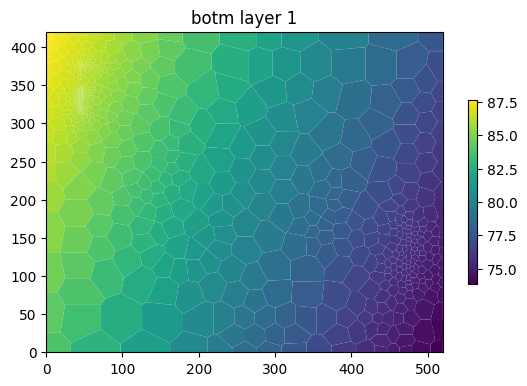

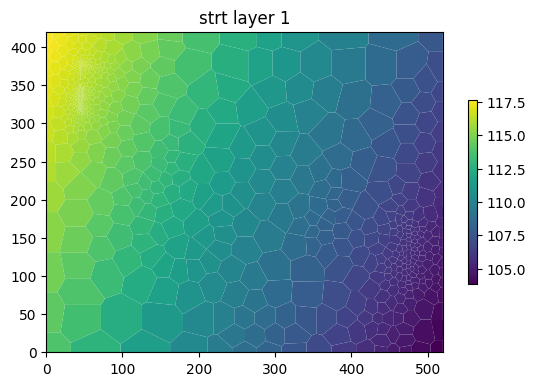

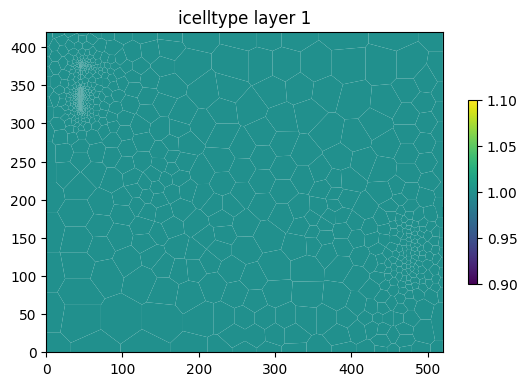

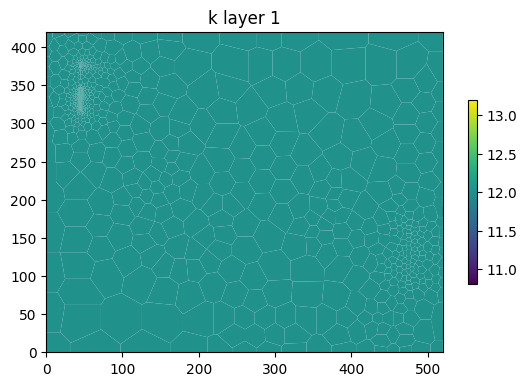

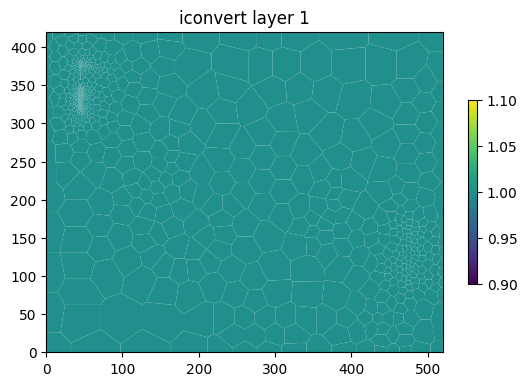

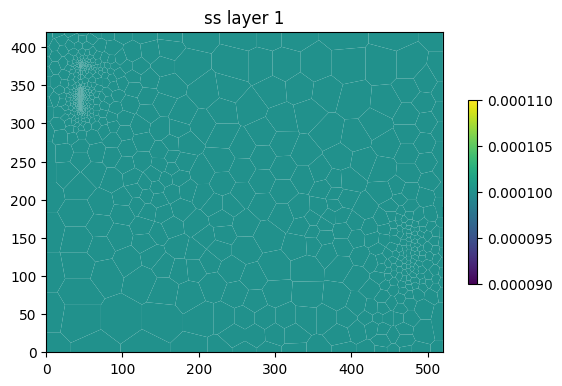

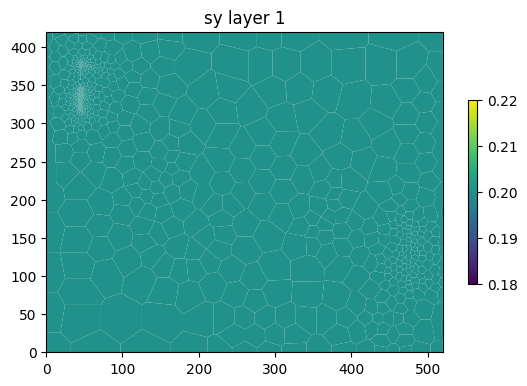

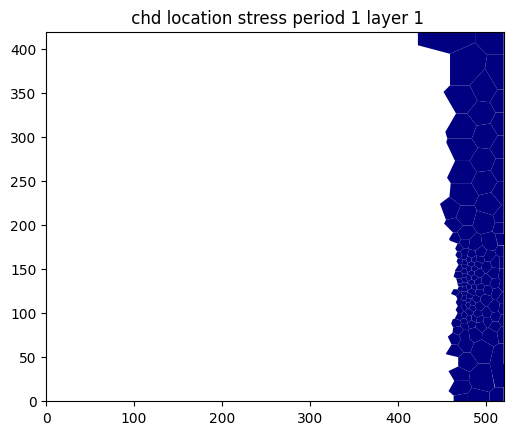

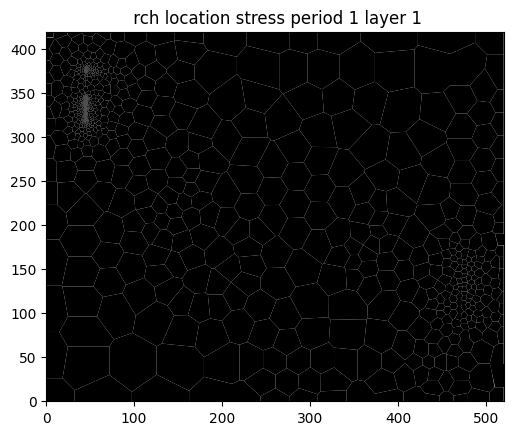

In [16]:
source_model.gwf.plot()